# Hour 2 · Notebook 1. Contrastive Learning: SimCLR on EuroSAT

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/remote_sensing/01_contrastive_simclr.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026: *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*
**Segment:** 2.2. Contrastive learning (slides 32-36) · Instantiates Hour 1, Section 1.4 · Figure 2A

---

This notebook adapts the classic SimCLR contrastive-learning recipe to the remote
sensing setting, and it establishes the pattern every subsequent notebook follows: markdown
theory → code → training → a visual result → interpretation.

**Mechanism: instance discrimination.** Two augmented views of the same EuroSAT patch are
pulled together in embedding space; every other patch in the batch is pushed apart. There is
no reconstruction target and no teacher network. The *only* signal is "these two views come
from the same image, all others don't."

### The InfoNCE loss

For a batch of $N$ images, we draw two augmented views of each, giving $2N$ views total. Let
$z_i$ be the projected embedding of view $i$. For a positive pair $(i,j)$ (two views of the
same underlying image), the InfoNCE loss is:

$$
\ell_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k)/\tau)}
$$

where $\text{sim}(z_i, z_j) = \dfrac{z_i^\top z_j}{\|z_i\|\,\|z_j\|}$ is cosine similarity and
$\tau$ (temperature) controls how peaked the softmax distribution over negatives is. Minimizing
this loss is exactly maximizing agreement between the two views relative to every other patch
in the batch, the mechanism from Hour 1, Section 1.4.

In [1]:
## Standard libraries
import os
import urllib.request
from urllib.error import HTTPError

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## tqdm for loading bars
from tqdm.auto import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torchvision
from torchvision import transforms

%matplotlib inline

c:\Users\stiva\anaconda3\envs\bepe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make the shared tutorial module importable.
# Local clone: it lives in src/remote_sensing/. Colab: download it next to this notebook.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "remote_sensing")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_rs.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_rs.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/remote_sensing/tutorial_rs.py", "tutorial_rs.py")

from tutorial_rs import (
    seed_everything, get_device, setup_plotting,
    EUROSAT_CLASSES, EUROSAT_MEAN, EUROSAT_STD, IMG_SIZE,
    load_eurosat, stratified_split,
    ContrastiveTransformations, build_rs_augmentations, build_eval_transform, denormalize,
    build_vit_s8, try_load_checkpoint,
    show_image_grid, plot_curve, plot_embedding_scatter,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)

DATASET_PATH = "../../data"
CHECKPOINT_PATH = "../../artifacts/remote_sensing/checkpoints"
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

Device: cuda:0


<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights live in this repository (Git LFS). Locally they are already on disk; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_vit_s8.pt", "mae_vit_s8.pt", "dino_vit_s8.pt", "random_init_vit_s8.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://media.githubusercontent.com/media/{_REPO}/main/artifacts/remote_sensing/checkpoints/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "remote_sensing", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


## Data: two independent views per image

We reuse the RS augmentation pipeline from Notebook 0 (mild jitter, free rotation/flips;
see that notebook for why) and wrap it in `ContrastiveTransformations` so that each call
returns **two** independently augmented views of the same patch.

In [3]:
rs_augmentations = build_rs_augmentations(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)

full_dataset = load_eurosat(DATASET_PATH, transform=ContrastiveTransformations(rs_augmentations, n_views=2))
train_idx, test_idx = stratified_split(full_dataset, test_size=0.2, seed=42)

# SSL pretraining uses only the train split, labels discarded
train_contrast = data.Subset(full_dataset, train_idx)
print(f"Contrastive training pool: {len(train_contrast)} images (labels discarded)")

Contrastive training pool: 21600 images (labels discarded)


In [4]:
train_loader = data.DataLoader(
    train_contrast, batch_size=256, shuffle=True, drop_last=True, num_workers=0, pin_memory=True
)

## Model: ViT encoder + projection head

Following SimCLR, we split the model into a base encoder $f(\cdot)$, our shared ViT-S/8,
and a small projection head $g(\cdot)$, a 2-layer MLP with a ReLU in between. The contrastive
loss is applied to $g(f(x))$; after pretraining, $g(\cdot)$ is discarded and only $f(\cdot)$
(the `[CLS]` embedding) is used as the representation, since $z = g(h)$ is trained to be
invariant to augmentation details that can still be useful downstream.

In [5]:
class SimCLRModel(nn.Module):
    def __init__(self, encoder, embed_dim=384, hidden_dim=512, proj_dim=128):
        super().__init__()
        self.encoder = encoder
        self.projection_head = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder.forward_features(x)  # [CLS] embedding, (B, embed_dim)
        z = self.projection_head(h)            # projected embedding, (B, proj_dim)
        return z

In [6]:
def info_nce_loss(feats, temperature=0.07):
    '''
    feats: (2N, proj_dim) embeddings, views of the same image at offset N apart.
    Returns: (scalar loss, cos_sim matrix, pos_mask) for logging.
    '''
    # TODO: info_nce
    raise NotImplementedError("Fill in info_nce -- see the notebook markdown above.")
    return loss, cos_sim, pos_mask


def info_nce_metrics(cos_sim, pos_mask):
    '''Ranking diagnostics: top-1 / top-5 accuracy of the positive among all negatives.'''
    comb_sim = torch.cat(
        [cos_sim[pos_mask][:, None], cos_sim.masked_fill(pos_mask, -9e15)], dim=-1
    )
    sim_argsort = comb_sim.argsort(dim=-1, descending=True).argmin(dim=-1)
    acc_top1 = (sim_argsort == 0).float().mean().item()
    acc_top5 = (sim_argsort < 5).float().mean().item()
    return acc_top1, acc_top5

## Live training on EuroSAT: SimCLR from scratch

We train the encoder **from random initialization** with SimCLR on EuroSAT. Nothing here has
seen a label, and nothing has been pretrained on another dataset: the only signal is the
InfoNCE objective over augmented views.

This matters for the comparison at the end of the notebook. Both encoders you will see, the one
trained here and the offline checkpoint, use the same architecture and the same SimCLR
objective from the same random start. The single variable is **how much pretraining compute**
each one received.

<div class="alert alert-info">

**What this cell shows vs. what we evaluate later.** This is a **short** run, enough to watch
the InfoNCE loss fall and top-1 accuracy rise, that is, to see the mechanism work. It is not a
full pretraining. The checkpoint loaded afterward was trained **offline, for 20,000 steps, on a
large Sentinel-2 corpus** (SeCo). We keep the weights from this cell so the two can be compared
directly, which is the point of the final figure: SSL from scratch is a *compute-hungry*
procedure, and seeing how far a few hundred steps gets you is the most honest way to show that.

</div>


100%|██████████| 400/400 [05:53<00:00,  1.13it/s]


Saved this notebook's encoder to ../../artifacts/remote_sensing/checkpoints\contrastive_vit_s8_notebook.pt


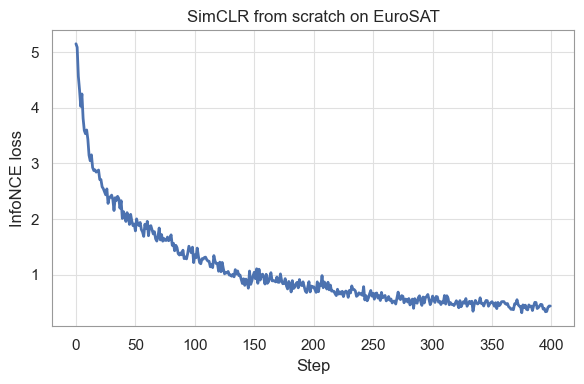

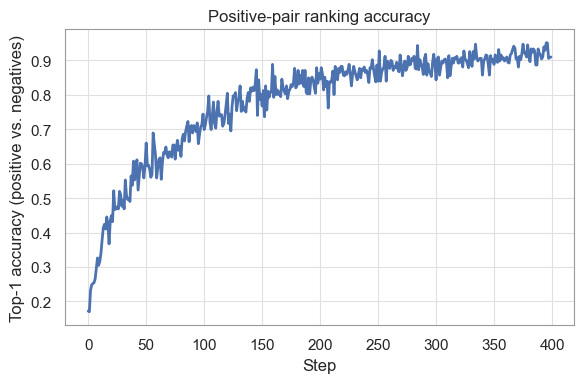

In [7]:
seed_everything(42)

# From-scratch: random init, no ImageNet weights. The only supervision is InfoNCE over views.
model = SimCLRModel(build_vit_s8()).to(device)

# A from-scratch run wants a larger LR than fine-tuning pretrained weights would.
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

# 400 steps rather than ~100: from a random start the encoder needs noticeably more updates
# before the embedding space shows any class structure at all in the t-SNE below. This is the
# slowest cell in the notebook (a few minutes on a GPU) and that cost *is* the lesson.
NUM_STEPS = 400
TEMPERATURE = 0.07

loss_history, acc1_history = [], []
data_iter = iter(train_loader)
model.train()

for step in tqdm(range(NUM_STEPS)):
    try:
        imgs, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        imgs, _ = next(data_iter)

    imgs = torch.cat(imgs, dim=0).to(device)  # (2N, C, H, W)
    feats = model(imgs)
    loss, cos_sim, pos_mask = info_nce_loss(feats, temperature=TEMPERATURE)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    acc1, _ = info_nce_metrics(cos_sim.detach(), pos_mask)
    loss_history.append(loss.item())
    acc1_history.append(acc1)

# Keep these weights: the final figure compares them against the long offline checkpoint, and
# Notebook 4 loads the same file for its frozen linear probe.
NOTEBOOK_CKPT = os.path.join(CHECKPOINT_PATH, "contrastive_vit_s8_notebook.pt")
torch.save(model.encoder.state_dict(), NOTEBOOK_CKPT)
print(f"Saved this notebook's encoder to {NOTEBOOK_CKPT}")

plot_curve(loss_history, xlabel="Step", ylabel="InfoNCE loss", title="SimCLR from scratch on EuroSAT")
plot_curve(acc1_history, xlabel="Step", ylabel="Top-1 accuracy (positive vs. negatives)", title="Positive-pair ranking accuracy")


## Loading the pretrained encoder

We now load the checkpoint pretrained offline on the large Sentinel-2 corpus. If it isn't
hosted yet, we fall back to using the briefly-trained model above so the rest of the notebook
still runs end-to-end.

In [8]:
pretrained_model = SimCLRModel(build_vit_s8()).to(device)
found = try_load_checkpoint(pretrained_model.encoder, CHECKPOINT_PATH, "contrastive_vit_s8.pt", device)
if not found:
    print("Falling back to the briefly-trained model from the live-training cell above.")
    pretrained_model = model

pretrained_model.eval()

Found pretrained model at ../../artifacts/remote_sensing/checkpoints\contrastive_vit_s8.pt, loading...


SimCLRModel(
  (encoder): ViTEncoder(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
    )
    (blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=1536, out_features=384, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  )
  (projection_head): Sequential(
    (0): Linear(in_features=384, out_features=512, bias=True)
    (1): ReLU(inplace=True)


## Visualizing the learned embedding space

We encode the held-out test split with the frozen encoder (no projection head) and reduce
the 384-dim `[CLS]` embeddings to 2D with t-SNE, colored by the *true* class label, which
the model never saw during pretraining.

In [9]:
eval_transform = build_eval_transform(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)
eval_dataset = load_eurosat(DATASET_PATH, transform=eval_transform)
test_subset = data.Subset(eval_dataset, test_idx)
test_loader = data.DataLoader(test_subset, batch_size=256, shuffle=False, num_workers=0)

all_feats, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader):
        imgs = imgs.to(device)
        feats = pretrained_model.encoder.forward_features(imgs)
        all_feats.append(feats.cpu())
        all_labels.append(labels)

all_feats = torch.cat(all_feats, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()
print("Encoded test features:", all_feats.shape)

100%|██████████| 22/22 [00:05<00:00,  3.98it/s]

Encoded test features: (5400, 384)


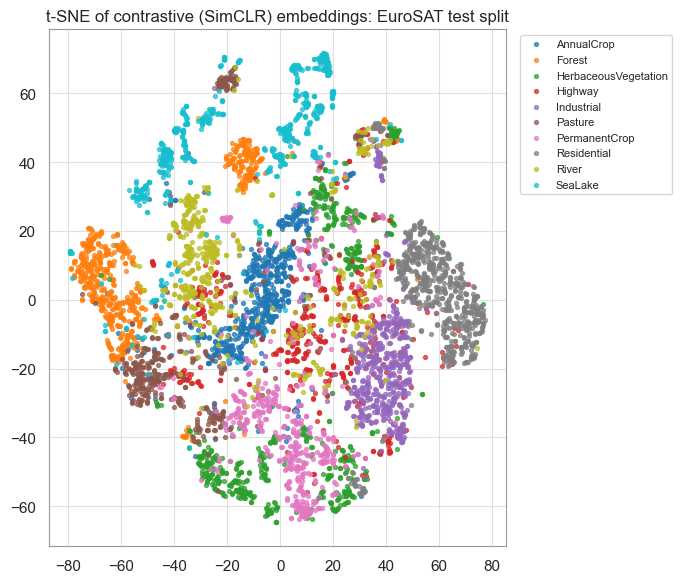

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30)
embedding_2d = tsne.fit_transform(all_feats)

plot_embedding_scatter(embedding_2d, all_labels, title="t-SNE of contrastive (SimCLR) embeddings: EuroSAT test split")

**Reading the scatter plot.** Clusters here reflect *instance-discrimination invariance*:
patches that the augmentation pipeline treats as "views of the same thing" end up nearby.
Since our augmentations are rotation/flip/mild-jitter, transformations that preserve land-cover
identity but not exact pixel layout, classes with consistent visual texture (Forest, SeaLake)
tend to separate cleanly, while visually heterogeneous classes (Highway vs. Residential, both
containing built structures) may overlap more. This is a direct, visual answer to "what did the
augmentation define as nuisance?" from Hour 1.

<div class="alert alert-info">

**Aside, beyond augmentations: seasonal positives.** In remote sensing we often have
something natural photography lacks: **repeat imaging of the same location over time**. SeCo
(Mañas et al., 2021) exploits this by treating two images of the *same coordinate* captured
in *different seasons* as a positive pair, instead of (or in addition to) synthetic
augmentations. This is a stronger, free-standing invariance signal. The model must learn
representations invariant to real seasonal appearance change, not just synthetic transforms.

</div>

## Next step: what does more pretraining compute buy?

The encoder above trained for 400 SimCLR steps on EuroSAT. The offline checkpoint used the
**same architecture, the same SimCLR objective and the same random initialization**, but ran
for 20,000 steps on the much larger SeCo Sentinel-2 corpus.

That makes the comparison below a controlled one. Everything is held fixed except the amount of
pretraining, so the difference between the panels is attributable to compute and data scale
rather than to a different method or a different starting point.

Both panels use the same architecture (ViT-S/8, 384-dim, 6 blocks), the same 64x64 native
resolution and the same t-SNE settings. Neither encoder ever saw a EuroSAT label.


In [11]:
# This notebook's encoder (400 steps, from scratch) as the reference point. We reload from the
# saved file rather than reusing `model`, so this cell also works on a fresh kernel where the
# training loop above was skipped.
notebook_encoder = build_vit_s8().to(device)
notebook_encoder.load_state_dict(torch.load(NOTEBOOK_CKPT, map_location=device))
notebook_encoder.eval()

notebook_feats = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc="notebook encoder (400 steps)"):
        notebook_feats.append(notebook_encoder.forward_features(imgs.to(device)).cpu())
notebook_feats = torch.cat(notebook_feats, dim=0).numpy()

print("Offline checkpoint (20k steps):", all_feats.shape)
print("This notebook (400 steps)    :", notebook_feats.shape)


notebook encoder (400 steps): 100%|██████████| 22/22 [00:03<00:00,  5.59it/s]

Offline checkpoint (20k steps): (5400, 384)
This notebook (400 steps)    : (5400, 384)


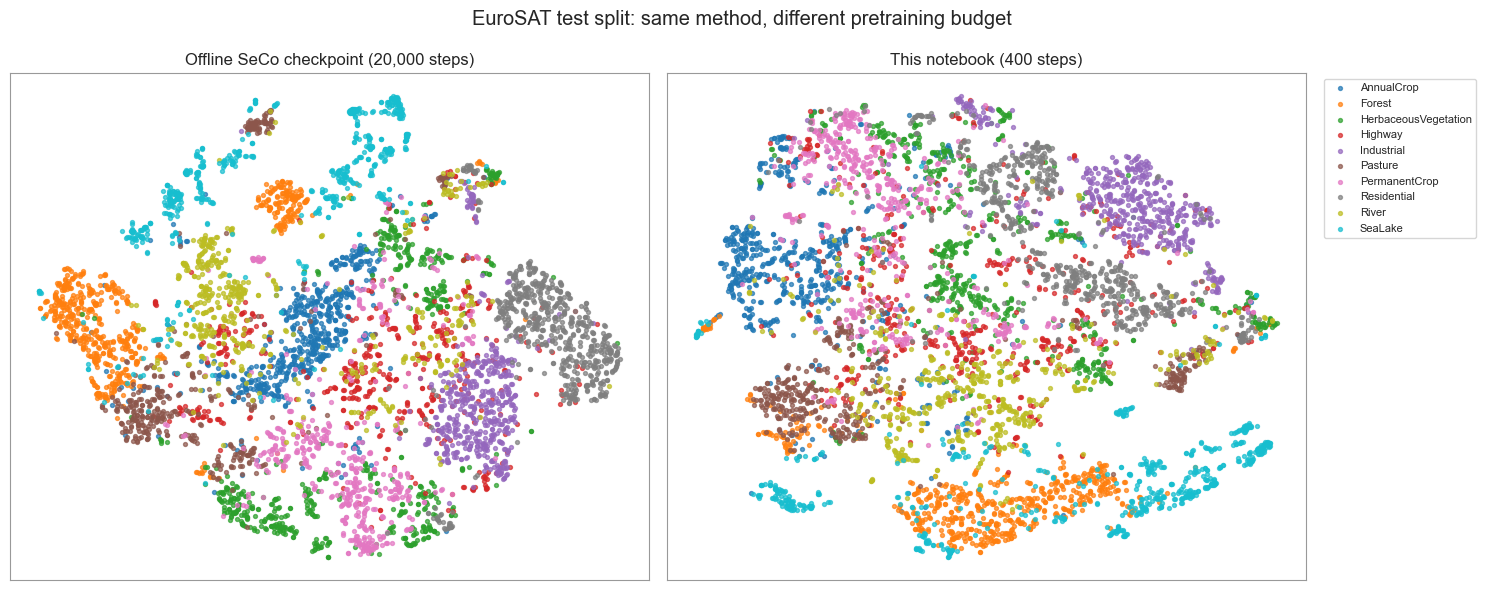

In [12]:
# Same t-SNE settings for both, so the two panels are directly comparable.
notebook_2d = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(notebook_feats)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cmap = plt.get_cmap("tab10")

for ax, emb, panel_title in [
    (axes[0], embedding_2d, "Offline SeCo checkpoint (20,000 steps)"),
    (axes[1], notebook_2d, "This notebook (400 steps)"),
]:
    for cls_idx, cls_name in enumerate(EUROSAT_CLASSES):
        mask = all_labels == cls_idx
        ax.scatter(emb[mask, 0], emb[mask, 1], s=8, color=cmap(cls_idx % 10),
                   label=cls_name, alpha=0.7)
    ax.set_title(panel_title)
    ax.set_xticks([]); ax.set_yticks([])

axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle("EuroSAT test split: same method, different pretraining budget")
plt.tight_layout()
plt.show()
plt.close()


**Reading the two panels.** Same architecture, same objective, same random initialization,
same input resolution and the same t-SNE settings. Neither encoder saw a EuroSAT label. The
only difference is the pretraining budget: 20,000 steps on SeCo versus 400 steps here.

Expect the left panel to show visibly more class structure. The right panel is a *400-step*
encoder, and 400 steps of SimCLR from a random start is very little: some coarse grouping may
appear, most classes will still be heavily mixed, and the layout may not look much better than
a random projection would. That is the honest result, and it is the point of the figure. SSL
does not fail here, it is simply nowhere near converged.

**Why show it at all?** Because the compute asymmetry is the practical lesson of this notebook.
The mechanism you implemented above is exactly the mechanism that produced the left panel; what
separates them is roughly a factor of fifty in steps, plus a corpus two orders of magnitude
larger. When you read "SimCLR works well on remote sensing," that is the scale the claim is
made at, and the short run should be read against it rather than against published numbers.

<div class="alert alert-info">

**What this plot can and cannot tell you.** A t-SNE panel shows *neighborhood structure*, not
downstream accuracy: the axes carry no units, distances between well-separated clusters are not
meaningful, and the layout shifts with `perplexity` and the random seed. Tighter-looking
clusters also do not automatically mean a better representation for a downstream task. Use this
to ask "what did this encoder consider similar?", and use Notebook 4's frozen linear probe,
which evaluates both of these encoders side by side, for the quantitative answer.

</div>


### References

- Chen, T., Kornblith, S., Norouzi, M., & Hinton, G. (2020). *A Simple Framework for
  Contrastive Learning of Visual Representations (SimCLR).* ICML.
- He, K., Fan, H., Wu, Y., Xie, S., & Girshick, R. (2020). *Momentum Contrast for
  Unsupervised Visual Representation Learning (MoCo).* CVPR.
- Mañas, O., Lacoste, A., Giró-i-Nieto, X., Vazquez, D., & Rodríguez, P. (2021). *Seasonal
  Contrast: Unsupervised Pre-Training from Uncurated Remote Sensing Data (SeCo).* ICCV.
- van den Oord, A., Li, Y., & Vinyals, O. (2018). *Representation Learning with Contrastive
  Predictive Coding.* arXiv:1807.03748.
- Stival, L. et al. (2025/2026). *[Tutorial paper, full citation TBD].*